In [1]:
!pip -q install simpy

import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("Setup Completo !!!")

Setup Completo !!!


In [3]:
# --- CONFIGURAÇÕES DO AMBIENTE ---
MINUTO_HORA = 60
MINUTO_DIA = 24 * MINUTO_HORA
DIAS_SIMULACAO = 14   # 2 semanas de mutirão
REPLICACOES = 30

# Função para definir a capacidade de atendimento conforme o horário
def obter_capacidade(tempo_atual, parametros):
    dia = int(tempo_atual // MINUTO_DIA)
    dia_semana = dia % 7
    minuto_dia = tempo_atual % MINUTO_DIA

    # UBS: Seg-Mex (07:00 - 17:00) | Sáb (08:00 - 14:00)
    if dia_semana < 5:  # Segunda a Sexta
        if 7*MINUTO_HORA <= minuto_dia < 13*MINUTO_HORA:
            return parametros['odonto_manha'], parametros['mulher_manha']
        elif 13*MINUTO_HORA <= minuto_dia < 17*MINUTO_HORA:
            return parametros['odonto_tarde'], parametros['mulher_tarde']
    elif dia_semana == 5:  # Sábado
        if 8*MINUTO_HORA <= minuto_dia < 14*MINUTO_HORA:
            return parametros['odonto_sab'], parametros['mulher_sab']
    return 0, 0

# Classe que representa a UBS durante o mutirão
class UBSMutirao:
    def __init__(self, ambiente, parametros):
        self.ambiente = ambiente
        self.parametros = parametros
        # Using simpy.Store to manage server tokens for dynamic capacity
        self.servidores_odonto = simpy.Store(ambiente)
        self.servidores_mulher = simpy.Store(ambiente)
        # To track the actual number of servers currently available/in-use
        self.current_cap_odonto = 0
        self.current_cap_mulher = 0
        self.dados = []
        self.ambiente.process(self.atualizar_recursos())

    def atualizar_recursos(self):
        while True:
            cap_odonto, cap_mulher = obter_capacidade(self.ambiente.now, self.parametros)

            # Adjust odonto servers
            if cap_odonto > self.current_cap_odonto:
                for _ in range(cap_odonto - self.current_cap_odonto):
                    # Add a server token to the store
                    yield self.servidores_odonto.put(object())
            elif cap_odonto < self.current_cap_odonto:
                # Remove tokens. This assumes idle servers are removed first.
                for _ in range(self.current_cap_odonto - cap_odonto):
                    if self.servidores_odonto.items: # Only remove if there's an idle server
                        # Take a server token from the store
                        yield self.servidores_odonto.get()
            self.current_cap_odonto = cap_odonto

            # Adjust mulher servers
            if cap_mulher > self.current_cap_mulher:
                for _ in range(cap_mulher - self.current_cap_mulher):
                    yield self.servidores_mulher.put(object())
            elif cap_mulher < self.current_cap_mulher:
                for _ in range(self.current_cap_mulher - cap_mulher):
                    if self.servidores_mulher.items:
                        yield self.servidores_mulher.get()
            self.current_cap_mulher = cap_mulher

            yield self.ambiente.timeout(1) # Update capacity every minute

# Processo de atendimento de pacientes
def processo_paciente(ambiente, ubs, fluxo):
    chegada = ambiente.now

    servidores = ubs.servidores_odonto if fluxo == 'odonto' else ubs.servidores_mulher
    current_capacity = ubs.current_cap_odonto if fluxo == 'odonto' else ubs.current_cap_mulher

    capacidade_fila = 36 if fluxo == 'odonto' else 40 # Max system capacity (queue + in-service)
    tempo_servico = 20 if fluxo == 'odonto' else 25

    # Calculate current number of patients in system (waiting for server + currently being served)
    # len(servidores.get_queue) = number of patients waiting for a server
    # (current_capacity - len(servidores.items)) = number of servers currently in use
    patients_in_system = len(servidores.get_queue) + (current_capacity - len(servidores.items))

    if patients_in_system < capacidade_fila:
        # Request a server token. If no tokens are available, the process will wait here.
        token = yield servidores.get()
        espera = ambiente.now - chegada
        ubs.dados.append({'fluxo': fluxo, 'espera': espera})
        yield ambiente.timeout(tempo_servico)
        yield servidores.put(token) # Release the server token
    else:
        ubs.dados.append({'fluxo': fluxo, 'evento': 'bloqueio', 'tempo': ambiente.now})

# Processo de chegada de pacientes
def gerador_chegadas(ambiente, ubs, fluxo, taxa_hora):
    taxa_minuto = taxa_hora / 60.0
    while True:
        yield ambiente.timeout(random.expovariate(taxa_minuto))
        ambiente.process(processo_paciente(ambiente, ubs, fluxo))

# Função para executar uma replicação da simulação
def executar_replicacao(parametros, semente):
    random.seed(semente)
    ambiente = simpy.Environment()
    ubs = UBSMutirao(ambiente, parametros)
    ambiente.process(gerador_chegadas(ambiente, ubs, 'odonto', 6))
    ambiente.process(gerador_chegadas(ambiente, ubs, 'mulher', 8))
    ambiente.run(until=DIAS_SIMULACAO * MINUTO_DIA)
    return pd.DataFrame(ubs.dados)

# --- EXECUÇÃO DOS CENÁRIOS ---
parametros_mutirao = {
    'odonto_manha': 3, 'odonto_tarde': 3, 'odonto_sab': 3,
    'mulher_manha': 4, 'mulher_tarde': 4, 'mulher_sab': 4
}

resultados = [executar_replicacao(parametros_mutirao, s) for s in range(REPLICACOES)]
df_final = pd.concat(resultados)
print(df_final.groupby('fluxo')['espera'].mean())

fluxo
mulher    16.949368
odonto    19.038779
Name: espera, dtype: float64


# Configurações iniciais da simulação

In [4]:
# --- CONFIGURAÇÕES DO AMBIENTE ---
MINUTO_HORA = 60
MINUTO_DIA = 24 * MINUTO_HORA
DIAS_SIMULACAO = 14   # 2 semanas de mutirão
REPLICACOES = 30      # número de replicações estatísticas

# --- CAPACIDADE DE PROFISSIONAIS POR TURNO ---
# Cenário atual (apenas concursados)
parametros_atual = {
    'odonto_manha': 1,   # 1 dentista concursado
    'odonto_tarde': 1,   # 1 dentista concursado
    'odonto_sab': 0,     # não há atendimento aos sábados
    'mulher_manha': 1,   # 1 médico ginecologista/obstetra concursado
    'mulher_tarde': 1,   # 1 médico concursado
    'mulher_sab': 0      # não há atendimento aos sábados
}

# Cenário mutirão (concursados + contratados)
parametros_mutirao = {
    'odonto_manha': 3,   # 3 dentistas (concursados + contratados)
    'odonto_tarde': 3,   # 3 dentistas
    'odonto_sab': 3,     # 3 dentistas aos sábados
    'mulher_manha': 4,   # 4 médicos (concursados + contratados)
    'mulher_tarde': 4,   # 4 médicos
    'mulher_sab': 4      # 4 médicos aos sábados
}


# Análise Gráfica da Simulação

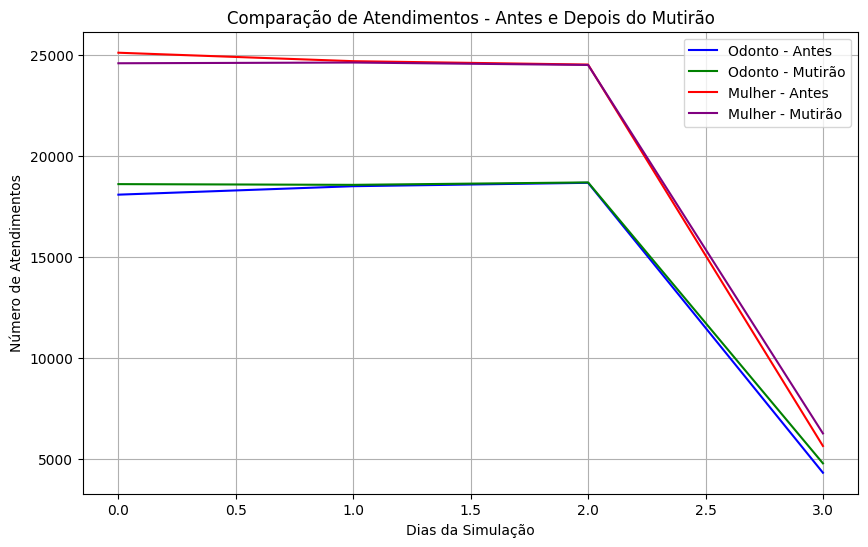

In [5]:
import matplotlib.pyplot as plt

# Supondo que df_final tenha os dados da simulação
# Vamos criar dois cenários: antes e depois do mutirão

# Cenário antes do mutirão (apenas concursados)
parametros_atual = {
    'odonto_manha': 1, 'odonto_tarde': 1, 'odonto_sab': 0,
    'mulher_manha': 1, 'mulher_tarde': 1, 'mulher_sab': 0
}
resultados_atual = [executar_replicacao(parametros_atual, s) for s in range(REPLICACOES)]
df_atual = pd.concat(resultados_atual)

# Cenário mutirão (contratados + sábado)
parametros_mutirao = {
    'odonto_manha': 3, 'odonto_tarde': 3, 'odonto_sab': 3,
    'mulher_manha': 4, 'mulher_tarde': 4, 'mulher_sab': 4
}
resultados_mutirao = [executar_replicacao(parametros_mutirao, s) for s in range(REPLICACOES)]
df_mutirao = pd.concat(resultados_mutirao)

# Contagem de atendimentos por dia
df_atual['dia'] = (df_atual.index // (MINUTO_DIA)).astype(int)
df_mutirao['dia'] = (df_mutirao.index // (MINUTO_DIA)).astype(int)

atend_atual = df_atual.groupby(['dia','fluxo']).size().unstack(fill_value=0)
atend_mutirao = df_mutirao.groupby(['dia','fluxo']).size().unstack(fill_value=0)

# Gráfico comparativo
plt.figure(figsize=(10,6))
plt.plot(atend_atual.index, atend_atual['odonto'], label='Odonto - Antes', color='blue')
plt.plot(atend_mutirao.index, atend_mutirao['odonto'], label='Odonto - Mutirão', color='green')
plt.plot(atend_atual.index, atend_atual['mulher'], label='Mulher - Antes', color='red')
plt.plot(atend_mutirao.index, atend_mutirao['mulher'], label='Mulher - Mutirão', color='purple')

plt.xlabel("Dias da Simulação")
plt.ylabel("Número de Atendimentos")
plt.title("Comparação de Atendimentos - Antes e Depois do Mutirão")
plt.legend()
plt.grid(True)
plt.show()